57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Taille de x_train : (404, 13)
Taille de x_test : (102, 13)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 574.2228 - mae: 22.0311 - val_loss: 613.9100 - val_mae: 22.9669
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 511.5630 - mae: 20.7465 - val_loss: 570.8522 - val_mae: 21.9841
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 480.2530 - mae: 19.9016 - val_loss: 518.2682 - val_mae: 20.7204
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 413.2769 - mae: 18.1721 - val_loss: 449.2417 - val_mae: 18.9960
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 361.2712 - mae: 16.5555 - val_loss: 364.3589 - val_mae: 16.7192
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 301.6709 - mae: 14.7221 - val_loss: 268.3054 - val_mae: 14.0205
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 210.2064 - mae: 12.0179 - val_loss: 173.2158 - val_mae: 10.8481
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 138.1394 - mae: 9.2898 - val_loss: 96.3937 - val_mae: 7.5134
Epoch 9/100
11/

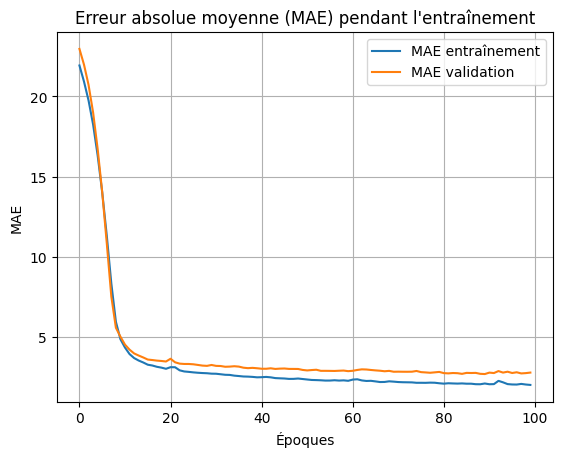

In [1]:
# Étape 1 : Importation des bibliothèques
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Étape 2 : Chargement des données
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()
print("Taille de x_train :", x_train.shape)
print("Taille de x_test :", x_test.shape)

# Étape 3 : Normalisation des caractéristiques
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Étape 4 : Définition de l'architecture du modèle
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # Couche de sortie sans activation pour une régression

# Étape 5 : Compilation du modèle
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Étape 6 : Entraînement du modèle
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Étape 7 : Évaluation sur l'ensemble de test
loss, mae = model.evaluate(x_test, y_test, verbose=2)
print("Erreur absolue moyenne (MAE) sur le test :", mae)

# Étape 8 : Prédiction sur un échantillon
sample = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample)
print("Valeur réelle :", y_test[0], "| Prédiction :", prediction[0][0])

# (Optionnel) Étape 9 : Visualisation de l’apprentissage
plt.plot(history.history['mae'], label='MAE entraînement')
plt.plot(history.history['val_mae'], label='MAE validation')
plt.xlabel('Époques')
plt.ylabel('MAE')
plt.title('Erreur absolue moyenne (MAE) pendant l\'entraînement')
plt.legend()
plt.grid(True)
plt.show()